# Apple Tasting — contextual algorithm comparison

Multi-algorithm comparison on the Apple Tasting game (contextual setting), in the style of
`run_comparison_at_v2.py`, with the multi-arm PG-TS added.

## Model

**Game** (`games.apple_tasting`; Helmbold, Littlestone & Long, 2000).  Two actions and two outcomes.

* **Action** $a \in \{0, 1\}$: $a = 1$ *accepts* the instance (and observes its class), $a = 0$ *rejects* it (no feedback).
* **Outcome** $y \in \{0, 1\}$: the class of the instance; accepting is correct for $y = 0$, rejecting for $y = 1$.
* **Loss** (matrix $L$) and **feedback** (matrix $H$):
$$
L = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \qquad
H = \begin{pmatrix} 1 & 1 \\ 1 & 0 \end{pmatrix}, \qquad
\ell(a, y) = L_{a,y} = \mathbb{1}\{a \ne 1 - y\}, \qquad \text{reward } r(a,y) = -\ell(a,y),
$$
  i.e. the learner observes $y$ only after playing $a = 1$ (signal matrix $S_1 = $ permutation, invertible), while
  $a = 0$ gives the constant signal.  The game is locally observable; neighbourhood $\mathcal{N} = \{(0, 1)\}$.

**Context and outcome model** (`synthetic_data.LinearContexts`, as in `run_comparison_at_v2.py`).  At each round the
raw features are $u_t \sim \mathrm{Unif}([0,1]^d)$ with $d = 10$; the algorithms receive the standardised context
$x_t = (u_t - \mu)/\sigma \in \mathbb{R}^d$.  The score is $s_t = w^\top u_t \in [0,1]$ with
$w \propto \mathrm{Unif}([0, 0.1]^{10})$ normalised to sum one (NumPy seed 1), and the conditional outcome distribution is
$$
q_t \;=\; \big(\Pr(y_t = 0 \mid x_t),\ \Pr(y_t = 1 \mid x_t)\big) \;=\; (s_t,\ 1 - s_t).
$$

**Protocol** (`evaluation_contextual.Evaluation_contextual`, as in the runner scripts).  The outcome is the deterministic
label $y_t = \mathbb{1}\{s_t \ge 1/2\}$, the learner plays $a_t$, observes the feedback $h(a_t, y_t)$, and the reported
quantity is the cumulative regret
$$
R_T \;=\; \sum_{t=1}^{T} \Big[\, \ell(a_t, y_t) \;-\; \min_{a}\, \ell(a, y_t) \Big].
$$

**Algorithms** (all from the code base, hyper-parameters of `run_comparison_at_v2.py`):
  - Random           — uniform baseline
  - PGTS             — Polya-Gamma Thompson Sampling
  - STAP-Helmbolt    — Helmbold et al.
  - PGTS-multi       — multi-arm PG-TS (`PGTS_multiarm.PGTSMultiArm`); identical model, sampler and decision rule
                       to PGTS on this game (per-arm intercept, prior mean 0 and 10 Gibbs updates by default)
  - CBPside          — Confidence Bounds for PM (deterministic)
  - RandCBPside      — Confidence Bounds for PM (randomized)
  - SquareCB.PMSide  — IGW + water-transfer (this work); identity operator (two actions)

Output (in `RESULTS_DIR`):
  - `comparison_at_results.npy`   (dict of {name: (N_SEEDS, HORIZON) array})
  - `comparison_at_regret.png`


In [1]:
import os
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt

from games import apple_tasting
from synthetic_data import LinearContexts
from evaluation_contextual import Evaluation_contextual
from squarecb_pmside import SquareCBPMSide
from STAP_Helmbolt import STAP_Helmbolt
from PGTS import PGTS
from PGTS_multiarm import PGTSMultiArm
from random_algo import Random
from cbpside import CBPside
from randcbpside import RandCPBside

In [2]:
# ── Experiment settings ────────────────────────────────────────────────────────
HORIZON = 3000
N_SEEDS = 5
D       = 10         # context dimension — must be >= 5 for CBPside/RandCBPside
GAMMA   = 1.0        # SquareCB.PMSide: effective rate gamma_t = GAMMA * sqrt(t)
LBD     = 0.05       # ridge regularisation (all ridge-regression algorithms)
ALPHA   = 1.01       # CBPside / RandCBPside confidence-bound exponent

# 10-dim weight vector matching the notebook setup (seed 1)
np.random.seed(1)
W = np.random.uniform(0, 0.1, D)
W = W / W.sum()

# RandCBPside-specific
SIGMA   = 5          # bandwidth for the randomised confidence level
K       = 10         # number of quantisation levels
EPSILON = 10e-7      # exploration probability floor

RESULTS_DIR = "results"   # where the raw results and the plot are saved

In [3]:
# ── Game / evaluator ──────────────────────────────────────────────────────────
with contextlib.redirect_stdout(io.StringIO()):
    game        = apple_tasting(restructure_game=False)
    context_gen = LinearContexts(W)
evaluator = Evaluation_contextual(HORIZON)

print(f"Game           : Apple Tasting  ({game.n_actions} actions, {game.n_outcomes} outcomes)")
print(f"Loss matrix    :\n{game.LossMatrix}")
print(f"Feedback matrix:\n{game.FeedbackMatrix}")
print(f"Neighbourhood  : {game.mathcal_N}")

Game           : Apple Tasting  (2 actions, 2 outcomes)
Loss matrix    :
[[1 0]
 [0 1]]
Feedback matrix:
[[1 1]
 [1 0]]
Neighbourhood  : [[0, 1]]


In [4]:
# ── Algorithm registry ────────────────────────────────────────────────────────
# Each entry: (display_name, factory_fn)
# factory_fn() returns a fresh algorithm instance.
ALGOS = [
    ("Random",
     lambda: Random(game, HORIZON)),

    ("PGTS",
     lambda: PGTS(game, D)),

    ("STAP-Helmbolt",
     lambda: STAP_Helmbolt(game, D)),

    ("PGTS-multi",
     lambda: PGTSMultiArm(game, D)),

    ("CBPside",
     lambda: CBPside(game, D, ALPHA, LBD)),

    ("RandCBPside",
     lambda: RandCPBside(game, D, ALPHA, LBD, SIGMA, K, EPSILON)),

    ("SquareCB.PMSide",
     lambda: SquareCBPMSide(game, d=D, gamma=GAMMA, lbd=LBD,
                            use_water_transfer=False)),
]

In [5]:
# ── Run all algorithms ─────────────────────────────────────────────────────────
results = {}

for name, factory in ALGOS:
    runs = []
    print(f"\nRunning {name}", end="", flush=True)

    for seed in range(N_SEEDS):
        # Suppress the verbose per-step prints from evaluation_contextual and the
        # algorithms (and the Gurobi messages of CBPside's constructor) so the
        # output stays readable.
        with contextlib.redirect_stdout(io.StringIO()):
            alg = factory()
            # reset() initialises contexts for algorithms that don't do it in __init__
            # (e.g. STAP_Helmbolt, RandCBPside).  Safe to call on all algorithms.
            alg.reset()
            cr = evaluator.eval_policy_once(alg, game, job=(context_gen, seed))

        runs.append(cr)
        print(f" {seed}", end="", flush=True)

    runs = np.array(runs)   # shape (N_SEEDS, HORIZON)
    results[name] = runs
    mean_final = runs.mean(axis=0)[-1]
    print(f"  |  mean cumulative regret @ T={HORIZON}: {mean_final:.2f}")

all_results = results


Running Random

 0

 1

 2

 3

...

 1

 2

 3

 4

  |  mean cumulative regret @ T=3000: 266.60


In [6]:
# ── Save raw results ───────────────────────────────────────────────────────────
os.makedirs(RESULTS_DIR, exist_ok=True)
np.save(os.path.join(RESULTS_DIR, "comparison_at_results.npy"), all_results)
print(f"Raw results saved to {RESULTS_DIR}/comparison_at_results.npy")

Raw results saved to results/comparison_at_results.npy


Plot saved to results/comparison_at_regret.png


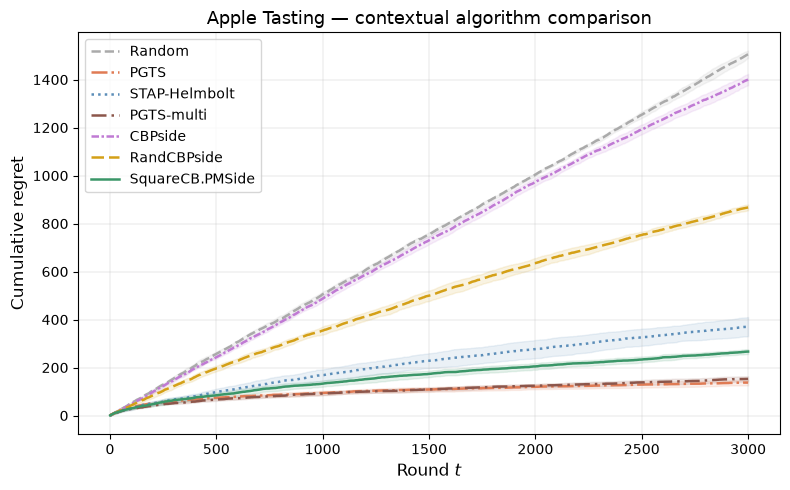

In [7]:
# ── Plot ───────────────────────────────────────────────────────────────────────
t      = np.arange(1, HORIZON + 1)
COLORS = {
    "Random":          "#aaaaaa",
    "PGTS":            "#e07b54",
    "PGTS-multi":      "#8c564b",
    "STAP-Helmbolt":   "#5b8db8",
    "CBPside":         "#c07ad4",
    "RandCBPside":     "#d4a017",
    "SquareCB.PMSide": "#3a9668",
}
STYLES = {
    "Random":          "--",
    "PGTS":            "-.",
    "PGTS-multi":      (0, (6, 2, 1, 2)),    # long dash-dot
    "STAP-Helmbolt":   ":",
    "CBPside":         (0, (3, 1, 1, 1)),   # dash-dot-dot
    "RandCBPside":     (0, (5, 2)),          # loose dash
    "SquareCB.PMSide": "-",
}

fig, ax = plt.subplots(figsize=(8, 5))

for name, _ in ALGOS:
    runs  = all_results[name]
    mean  = runs.mean(axis=0)
    std   = runs.std(axis=0)
    ax.plot(t, mean, label=name, color=COLORS[name],
            linewidth=1.8, linestyle=STYLES[name])
    ax.fill_between(t, mean - std, mean + std, alpha=0.12, color=COLORS[name])

ax.set_xlabel("Round $t$", fontsize=12)
ax.set_ylabel("Cumulative regret", fontsize=12)
ax.set_title("Apple Tasting — contextual algorithm comparison", fontsize=13)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, linewidth=0.35, alpha=0.6)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "comparison_at_regret.png"), dpi=150)
print(f"Plot saved to {RESULTS_DIR}/comparison_at_regret.png")